# DI725 Assignment 1 — Customer Service Sentiment Analysis
**Graduate School of Informatics — Transformers and Attention-Based Deep Networks**

This notebook implements sentiment classification on customer service conversations using:
1. A custom Transformer trained from scratch (nanoGPT-based)
2. A fine-tuned GPT-2 model

**Sections:**
- [1. Setup & Installations](#1)
- [2. Imports & Configuration](#2)
- [3. Exploratory Data Analysis (EDA)](#3)
- [4. Data Preprocessing](#4)
- [5. Dataset & DataLoader](#5)
- [6. Model 1 — Custom Transformer (from scratch)](#6)
- [7. Training — Model 1](#7)
- [8. Model 2 — GPT-2 Fine-tuning](#8)
- [9. Training — Model 2](#9)
- [10. Evaluation & Results](#10)

## 1. Setup & Installations <a id='1'></a>

In [1]:
# Install required packages (uncomment if running on Colab)
!pip install transformers wandb scikit-learn pandas matplotlib seaborn torch

## 2. Imports & Configuration <a id='2'></a>

In [2]:
import os
import math
import time
import random
import inspect
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from transformers import GPT2Tokenizer, GPT2Model

import wandb

print("All imports successful.")
print(f"PyTorch version: {torch.__version__}")

All imports successful.
PyTorch version: 2.10.0+cu128


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 1337
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# ── Data paths ───────────────────────────────────────────────────────────────
# Update these paths if needed (e.g. Google Drive mount)
TRAIN_PATH = '/content/train.csv'
TEST_PATH  = '/content/test.csv'

# ── Label mapping ────────────────────────────────────────────────────────────
LABEL_MAP    = {'positive': 0, 'neutral': 1, 'negative': 2}
LABEL_NAMES  = ['positive', 'neutral', 'negative']
NUM_CLASSES  = 3

Using device: cuda


In [4]:
# ── WANDB Login ──────────────────────────────────────────────────────────────
# Paste your API key here or set the WANDB_API_KEY environment variable
wandb.login(key="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")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mchamurcu (mchamurcu-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

In [5]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw  = pd.read_csv(TEST_PATH)

print(f"Train shape : {df_train_raw.shape}")
print(f"Test shape  : {df_test_raw.shape}")
print()
print("Columns:", df_train_raw.columns.tolist())
df_train_raw.head(2)

Train shape : (970, 11)
Test shape  : (30, 11)

Columns: ['issue_area', 'issue_category', 'issue_sub_category', 'issue_category_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'agent_experience_level_desc', 'conversation']


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...


In [6]:
# ── Missing values ────────────────────────────────────────────────────────────
print("Missing values in train:")
print(df_train_raw.isnull().sum())
print()
print("Missing values in test:")
print(df_test_raw.isnull().sum())

Missing values in train:
issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64

Missing values in test:
issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64


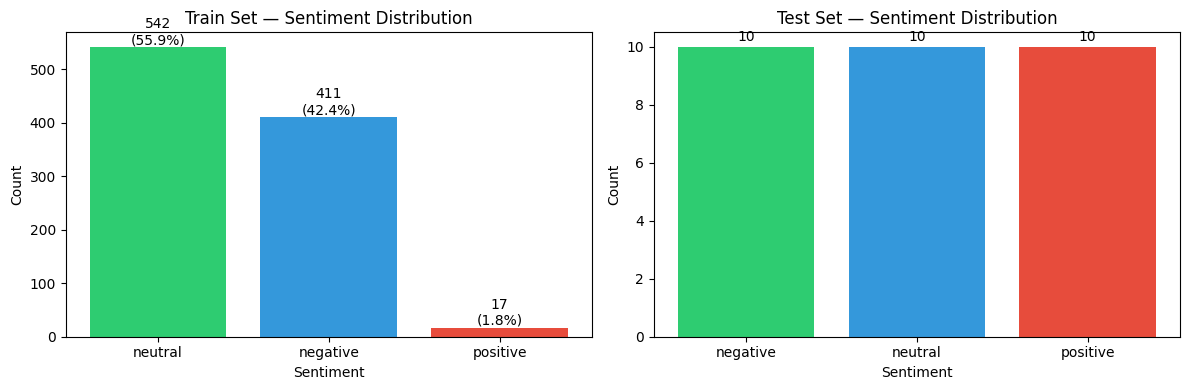


Key observation: Train set is highly imbalanced (positive: ~1.8%),
whereas the test set is perfectly balanced (10 per class).


In [7]:
# ── Sentiment Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
train_counts = df_train_raw['customer_sentiment'].value_counts()
axes[0].bar(train_counts.index, train_counts.values,
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Train Set — Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df_train_raw)*100:.1f}%)',
                 ha='center', fontsize=10)

# Test
test_counts = df_test_raw['customer_sentiment'].value_counts()
axes[1].bar(test_counts.index, test_counts.values,
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Test Set — Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 0.2, f'{v}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observation: Train set is highly imbalanced (positive: ~1.8%),")
print("whereas the test set is perfectly balanced (10 per class).")

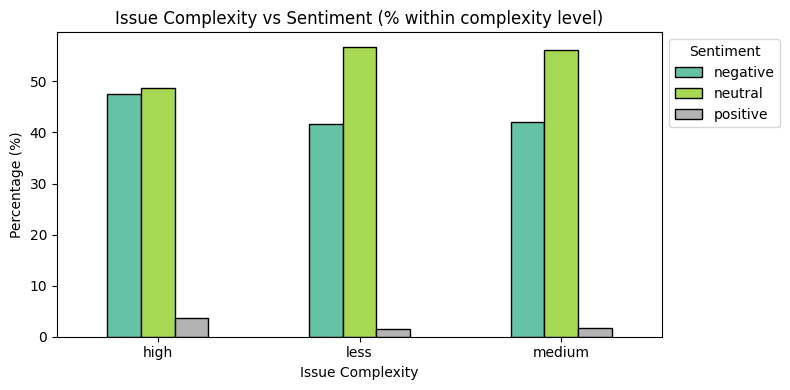

In [8]:
# ── Correlation: Issue Complexity vs Sentiment ─────────────────────────────────
ct = pd.crosstab(df_train_raw['issue_complexity'],
                 df_train_raw['customer_sentiment'],
                 normalize='index') * 100
ct.plot(kind='bar', figsize=(8, 4), colormap='Set2', edgecolor='black')
plt.title('Issue Complexity vs Sentiment (% within complexity level)')
plt.ylabel('Percentage (%)')
plt.xlabel('Issue Complexity')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('complexity_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

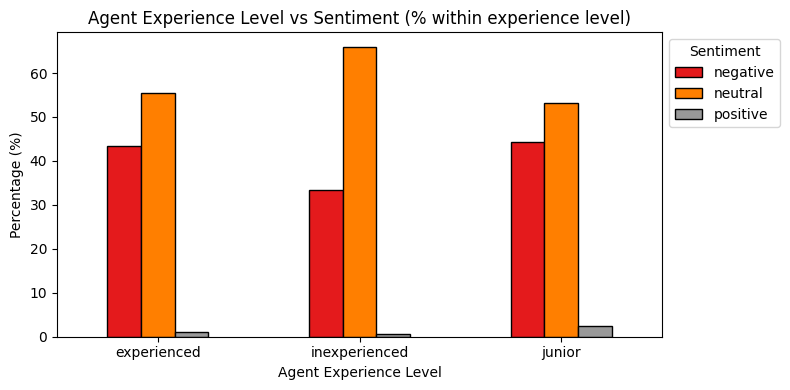

In [9]:
# ── Correlation: Agent Experience vs Sentiment ──────────────────────────────────
ct2 = pd.crosstab(df_train_raw['agent_experience_level'],
                  df_train_raw['customer_sentiment'],
                  normalize='index') * 100
ct2.plot(kind='bar', figsize=(8, 4), colormap='Set1', edgecolor='black')
plt.title('Agent Experience Level vs Sentiment (% within experience level)')
plt.ylabel('Percentage (%)')
plt.xlabel('Agent Experience Level')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('agent_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

Conversation character length statistics:
count     970.0
mean     2129.0
std       565.0
min        46.0
25%      1760.0
50%      2058.0
75%      2430.0
max      5708.0
Name: conv_char_len, dtype: float64

Conversation word count statistics:
count    970.0
mean     371.0
std       98.0
min        8.0
25%      306.0
50%      357.0
75%      424.0
max      992.0
Name: conv_word_len, dtype: float64


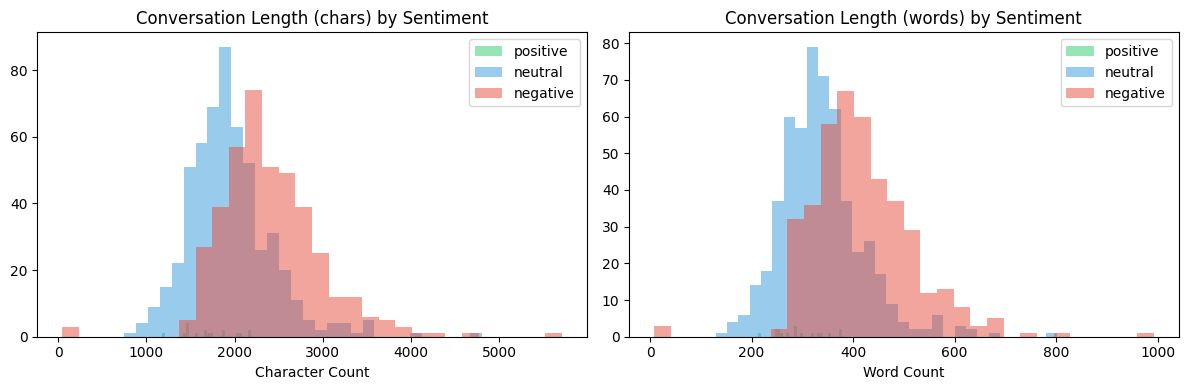

In [10]:
# ── Conversation Length Distribution ──────────────────────────────────────────
df_train_raw['conv_char_len'] = df_train_raw['conversation'].str.len()
df_train_raw['conv_word_len'] = df_train_raw['conversation'].str.split().str.len()

print("Conversation character length statistics:")
print(df_train_raw['conv_char_len'].describe().round(0))
print()
print("Conversation word count statistics:")
print(df_train_raw['conv_word_len'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sent, color in zip(['positive', 'neutral', 'negative'],
                        ['#2ecc71', '#3498db', '#e74c3c']):
    subset = df_train_raw[df_train_raw['customer_sentiment'] == sent]
    axes[0].hist(subset['conv_char_len'], bins=30, alpha=0.5,
                 label=sent, color=color)
    axes[1].hist(subset['conv_word_len'], bins=30, alpha=0.5,
                 label=sent, color=color)

axes[0].set_title('Conversation Length (chars) by Sentiment')
axes[0].set_xlabel('Character Count')
axes[0].legend()
axes[1].set_title('Conversation Length (words) by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('conv_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing <a id='4'></a>

**Preprocessing decisions:**
- We use only the `conversation` and `customer_sentiment` columns. Other features (issue area, product category, etc.) are categorical metadata that could introduce shortcuts rather than teaching the model to understand sentiment from text.
- Conversations contain both Agent and Customer lines. We **extract only the Customer turns** because sentiment classification targets the *customer's* emotional state, not the agent's scripted responses.
- We lowercase text and strip excess whitespace.
- We split train into train (80%) and validation (20%) using stratified split to preserve class ratios.

In [11]:
import re

def extract_customer_turns(conversation: str) -> str:
    """
    Extract only the customer's lines from the conversation.
    Lines starting with 'Customer:' are kept; agent lines are dropped.
    Tries both literal '\\n' and actual newline as delimiters.
    """
    # Try literal '\n' first (common in CSV exports), then actual newline
    if '\\n' in conversation:
        lines = conversation.split('\\n')
    else:
        lines = conversation.split('\n')

    customer_lines = [
        re.sub(r'^Customer:\s*', '', line).strip()
        for line in lines
        if line.strip().lower().startswith('customer:')
    ]

    # If no customer lines found, use the full conversation as fallback
    if not customer_lines:
        return conversation
    return ' '.join(customer_lines)


def clean_text(text: str) -> str:
    """Lowercase and remove redundant whitespace."""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    """Apply full preprocessing pipeline to a dataframe."""
    df = df.copy()
    df['processed_text'] = (
        df['conversation']
        .apply(extract_customer_turns)
        .apply(clean_text)
    )
    df['label'] = df['customer_sentiment'].map(LABEL_MAP)

    # Sanity check: warn if processed texts are too short
    avg_len = df['processed_text'].str.len().mean()
    empty_count = (df['processed_text'].str.len() == 0).sum()
    print(f"Average processed text length: {avg_len:.0f} chars")
    print(f"Empty processed texts: {empty_count}")

    return df[['processed_text', 'customer_sentiment', 'label']]


# Apply preprocessing
df_full_proc = preprocess_df(df_train_raw)
df_test_proc = preprocess_df(df_test_raw)

# Sanity check
print("\nProcessed text sample:")
print(df_full_proc['processed_text'].iloc[0][:300])
print()
print("Processed text length stats:")
print(df_full_proc['processed_text'].str.len().describe().round(0))


Average processed text length: 535 chars
Empty processed texts: 0
Average processed text length: 534 chars
Empty processed texts: 0

Processed text sample:
hi tom, i'm trying to log in to my account to purchase an oven toaster grill (otg), but i'm unable to proceed as it's asking for mobile number or email verification. can you help me with that? my registered mobile number is +1 123-456-7890. oh, i'm sorry. i might have registered with a different num

Processed text length stats:
count     970.0
mean      535.0
std       147.0
min        46.0
25%       441.0
50%       520.0
75%       613.0
max      1439.0
Name: processed_text, dtype: float64


In [12]:
# ── Train / Validation split (stratified) ─────────────────────────────────────
df_train, df_val = train_test_split(
    df_full_proc,
    test_size=0.2,
    random_state=SEED,
    stratify=df_full_proc['label']
)

print(f"Train size      : {len(df_train)}")
print(f"Validation size : {len(df_val)}")
print(f"Test size       : {len(df_test_proc)}")
print()
print("Train label distribution:")
print(df_train['customer_sentiment'].value_counts())
print()
print("Val label distribution:")
print(df_val['customer_sentiment'].value_counts())

Train size      : 776
Validation size : 194
Test size       : 30

Train label distribution:
customer_sentiment
neutral     434
negative    329
positive     13
Name: count, dtype: int64

Val label distribution:
customer_sentiment
neutral     108
negative     82
positive      4
Name: count, dtype: int64


## 5. Dataset & DataLoader <a id='5'></a>

In [13]:
class SentimentDataset(Dataset):
    """
    PyTorch Dataset for sentiment classification.
    Supports optional positive-class augmentation via repetition
    to partially address the severe class imbalance (positive ~1.8%).
    """

    def __init__(self, df: pd.DataFrame, tokenizer,
                 max_length: int = 128, augment_positive: bool = False):
        self.texts  = df['processed_text'].tolist()
        self.labels = df['label'].tolist()

        # Oversample positive class (label=0) by repeating 3 times
        if augment_positive:
            pos_idx = [i for i, l in enumerate(self.labels) if l == 0]
            for _ in range(3):
                for idx in pos_idx:
                    self.texts.append(self.texts[idx])
                    self.labels.append(0)

        # Tokenize all texts once at construction time
        self.input_ids      = []
        self.attention_masks = []
        for text in self.texts:
            enc = tokenizer(
                text,
                truncation=True,
                max_length=max_length,
                padding='max_length',
                return_attention_mask=True
            )
            self.input_ids.append(enc['input_ids'])
            self.attention_masks.append(enc['attention_mask'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.input_ids[idx],       dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_masks[idx], dtype=torch.long),
            'labels':         torch.tensor(self.labels[idx],          dtype=torch.long)
        }


def make_weighted_sampler(dataset: SentimentDataset,
                          class_weights_np: np.ndarray) -> WeightedRandomSampler:
    """Create a WeightedRandomSampler to further combat class imbalance."""
    sample_weights = [class_weights_np[label] for label in dataset.labels]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


print("Dataset class defined.")

Dataset class defined.


## 6. Model 1 — Custom Transformer (from scratch) <a id='6'></a>

Architecture based on nanoGPT, adapted for classification:
- Causal self-attention layers with residual connections
- Replaced the language-model head with a classification head
- Global average pooling over the sequence dimension before classification
- Increased dropout (0.3) for regularization on a small dataset

In [14]:
# ── Building blocks ───────────────────────────────────────────────────────────

class LayerNorm(nn.Module):
    """LayerNorm with an optional bias (PyTorch built-in does not support bias=False)."""
    def __init__(self, ndim: int, bias: bool):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias   = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


class CausalSelfAttention(nn.Module):
    """Multi-head self-attention with optional padding mask."""
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn      = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj      = nn.Linear(config.n_embd, config.n_embd,     bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x, attention_mask=None):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        head_dim = C // self.n_head
        k = k.view(B, T, self.n_head, head_dim).transpose(1, 2)
        q = q.view(B, T, self.n_head, head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_dim))
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
            att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    """Position-wise feed-forward network."""
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    """Transformer block: LayerNorm → Attention → Residual → LayerNorm → MLP → Residual."""
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp  = MLP(config)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln_1(x), attention_mask=attention_mask)
        x = x + self.mlp(self.ln_2(x))
        return x


@dataclass
class SentimentConfig:
    block_size:  int   = 256          # Increased to capture more of the conversation
    vocab_size:  int   = 50304        # GPT-2 vocab size (padded to multiple of 64)
    n_layer:     int   = 4            # Reduced from 6 — less overfitting on 970 samples
    n_head:      int   = 4            # Reduced from 6
    n_embd:      int   = 256          # Reduced from 384 — ~7M params instead of 30M
    dropout:     float = 0.4          # Increased dropout for small dataset
    bias:        bool  = True
    num_classes: int   = 3


class SentimentTransformer(nn.Module):
    """
    Custom Transformer for sentiment classification.
    Key modifications over nanoGPT:
    - Replaced the LM head with a classification head
    - Masked mean pooling (ignores padding tokens)
    - Attention mask support throughout the model
    """

    def __init__(self, config: SentimentConfig):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.classifier = nn.Sequential(
            nn.Linear(config.n_embd, config.n_embd),
            nn.Tanh(),
            nn.Dropout(config.dropout),
            nn.Linear(config.n_embd, config.num_classes)
        )
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))
        print(f"Parameters: {sum(p.numel() for p in self.parameters()) / 1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, attention_mask=None, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size
        pos = torch.arange(T, dtype=torch.long, device=idx.device).unsqueeze(0)
        x = self.transformer.drop(
            self.transformer.wte(idx) + self.transformer.wpe(pos)
        )
        for block in self.transformer.h:
            x = block(x, attention_mask=attention_mask)
        x = self.transformer.ln_f(x)
        if attention_mask is not None:
            mask_exp = attention_mask.unsqueeze(-1).float()
            pooled = (x * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1e-9)
        else:
            pooled = x.mean(dim=1)
        logits = self.classifier(pooled)
        loss = F.cross_entropy(logits, targets) if targets is not None else None
        return logits, loss


print("Custom Transformer architecture defined.")


Custom Transformer architecture defined.


## 7. Training — Model 1 (Custom Transformer) <a id='7'></a>

In [15]:
def compute_loss(logits, targets, class_weights, gamma=2.0, smoothing=0.1):
    """
    Weighted cross-entropy with label smoothing.
    Focal loss component is kept but with reduced gamma for stability.
    """
    num_classes = logits.size(-1)
    # Label smoothing
    with torch.no_grad():
        smooth_targets = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth_targets = smooth_targets * (1 - smoothing) + smoothing / num_classes
    log_probs = F.log_softmax(logits, dim=1)
    loss = -(smooth_targets * log_probs).sum(dim=1)
    # Focal weighting
    pt = torch.exp(-loss)
    focal_weight = (1 - pt) ** gamma
    # Class weighting
    sample_w = class_weights[targets]
    return (focal_weight * loss * sample_w).mean()


print("Loss function defined.")


Loss function defined.


In [16]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
SCRATCH_CFG = dict(
    learning_rate      = 3e-4,
    batch_size         = 16,
    num_epochs         = 60,
    weight_decay       = 0.05,      # Increased regularization
    max_length         = 256,       # Increased from 128 to capture more text
    gamma              = 1.0,       # Reduced focal gamma for stability
    label_smoothing    = 0.1,
    early_stop_patience= 15,        # More patience — val metrics are noisy with 4 positives
)

# ── WANDB init ────────────────────────────────────────────────────────────────
wandb.init(
    project="DI725-assignment1-2025S",
    config={**SCRATCH_CFG, "architecture": "custom-transformer", "dataset": "customer_service_sentiment"}
)

# ── Tokenizer & Datasets ──────────────────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

train_ds = SentimentDataset(df_train, tokenizer,
                             max_length=SCRATCH_CFG['max_length'],
                             augment_positive=True)
val_ds   = SentimentDataset(df_val,   tokenizer,
                             max_length=SCRATCH_CFG['max_length'])
test_ds  = SentimentDataset(df_test_proc, tokenizer,
                             max_length=SCRATCH_CFG['max_length'])

# ── Class weights for imbalance ───────────────────────────────────────────────
y_train_np      = np.array(df_train['label'].tolist())
cw_np           = compute_class_weight('balanced', classes=np.unique(y_train_np), y=y_train_np)
cw_np[0]       *= 2.0   # Extra boost for positive class (only 13 in train)
class_weights_t = torch.FloatTensor(cw_np).to(DEVICE)
print(f"Class weights: {cw_np.round(3)}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
sampler    = make_weighted_sampler(train_ds, cw_np)
train_loader = DataLoader(train_ds, batch_size=SCRATCH_CFG['batch_size'], sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=SCRATCH_CFG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=SCRATCH_CFG['batch_size'], shuffle=False)

# ── Model, optimizer, scheduler ──────────────────────────────────────────────
cfg_scratch   = SentimentConfig(block_size=SCRATCH_CFG['max_length'])
model_scratch = SentimentTransformer(cfg_scratch).to(DEVICE)

optimizer = torch.optim.AdamW(
    model_scratch.parameters(),
    lr=SCRATCH_CFG['learning_rate'],
    weight_decay=SCRATCH_CFG['weight_decay']
)
total_steps   = SCRATCH_CFG['num_epochs'] * len(train_loader)
warmup_steps  = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Class weights: [39.795  0.596  0.786]
Parameters: 16.17M


In [17]:
# ── Training loop ─────────────────────────────────────────────────────────────
best_val_f1     = 0.0
no_improve      = 0

for epoch in range(SCRATCH_CFG['num_epochs']):
    model_scratch.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        inputs  = batch['input_ids'].to(DEVICE)
        mask    = batch['attention_mask'].to(DEVICE)
        targets = batch['labels'].to(DEVICE)

        logits, _ = model_scratch(inputs, attention_mask=mask, targets=targets)
        loss = compute_loss(
            logits, targets, class_weights_t,
            gamma=SCRATCH_CFG['gamma'],
            smoothing=SCRATCH_CFG['label_smoothing']
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        wandb.log({"scratch/train_batch_loss": loss.item(),
                   "scratch/lr": scheduler.get_last_lr()[0]})

    avg_train_loss = total_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────────────────────
    model_scratch.eval()
    val_loss, all_preds, all_tgts = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            inputs  = batch['input_ids'].to(DEVICE)
            mask    = batch['attention_mask'].to(DEVICE)
            targets = batch['labels'].to(DEVICE)
            logits, _ = model_scratch(inputs, attention_mask=mask, targets=targets)
            loss = compute_loss(
                logits, targets, class_weights_t,
                gamma=SCRATCH_CFG['gamma'], smoothing=0.0
            )
            val_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_tgts.extend(targets.cpu().numpy())

    val_loss  /= len(val_loader)
    accuracy   = accuracy_score(all_tgts, all_preds)
    f1_w       = f1_score(all_tgts, all_preds, average='weighted', zero_division=0)
    f1_macro   = f1_score(all_tgts, all_preds, average='macro',    zero_division=0)
    f1_per     = f1_score(all_tgts, all_preds, average=None,       zero_division=0)

    print(f"Epoch {epoch+1:02d} | train={avg_train_loss:.4f} "
          f"val={val_loss:.4f} acc={accuracy:.3f} "
          f"F1m={f1_macro:.3f} [pos={f1_per[0]:.2f} neu={f1_per[1]:.2f} neg={f1_per[2]:.2f}]")

    wandb.log({"scratch/epoch": epoch+1,
               "scratch/train_epoch_loss": avg_train_loss,
               "scratch/val_loss": val_loss,
               "scratch/val_accuracy": accuracy,
               "scratch/val_f1_weighted": f1_w,
               "scratch/val_f1_macro": f1_macro})

    if f1_macro > best_val_f1:
        best_val_f1 = f1_macro
        no_improve  = 0
        os.makedirs('models', exist_ok=True)
        torch.save(model_scratch.state_dict(), 'models/scratch_best.pt')
        #print(f"  → Saved (f1_macro={f1_macro:.4f})")
    else:
        no_improve += 1
        if no_improve >= SCRATCH_CFG['early_stop_patience']:
            print("Early stopping triggered.")
            break

wandb.finish()
print(f"\nTraining complete. Best val F1 (macro): {best_val_f1:.4f}")


Epoch 01 | train=10.0400 val=2.0846 acc=0.021 F1m=0.013 [pos=0.04 neu=0.00 neg=0.00]
  → Saved (f1_macro=0.0135)
Epoch 02 | train=2.8147 val=2.0910 acc=0.021 F1m=0.013 [pos=0.04 neu=0.00 neg=0.00]
Epoch 03 | train=3.0978 val=2.0153 acc=0.428 F1m=0.284 [pos=0.25 neu=0.00 neg=0.60]
  → Saved (f1_macro=0.2843)
Epoch 04 | train=2.5598 val=1.0225 acc=0.485 F1m=0.381 [pos=0.24 neu=0.27 neg=0.63]
  → Saved (f1_macro=0.3814)
Epoch 05 | train=2.4133 val=1.7930 acc=0.448 F1m=0.411 [pos=0.57 neu=0.05 neg=0.61]
  → Saved (f1_macro=0.4110)
Epoch 06 | train=2.4494 val=0.5616 acc=0.619 F1m=0.511 [pos=0.16 neu=0.58 neg=0.79]
  → Saved (f1_macro=0.5109)
Epoch 07 | train=2.4817 val=1.5189 acc=0.691 F1m=0.536 [pos=0.15 neu=0.66 neg=0.80]
  → Saved (f1_macro=0.5357)
Epoch 08 | train=2.4915 val=1.9551 acc=0.701 F1m=0.579 [pos=0.33 neu=0.65 neg=0.75]
  → Saved (f1_macro=0.5786)
Epoch 09 | train=2.4985 val=2.1845 acc=0.737 F1m=0.606 [pos=0.33 neu=0.72 neg=0.77]
  → Saved (f1_macro=0.6056)
Epoch 10 | train=2.

scratch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
scratch/lr,▂▄▅▅████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
scratch/train_batch_loss,█▆▇▄▃▂▄▆▃▆▃▃▅▄▅▄▄▂▃▂▂▅▂▆▇▂▄▄▁▃▆▆▃▄▄▄▅▃▃▄
scratch/train_epoch_loss,▆█▃▂▃▃▂▃▃▂▁▂▂▃▁▂▃▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂
scratch/val_accuracy,▁▁▄▅▄▆▆▇▇▇▇▇█▇▇█████████████████████████
scratch/val_f1_macro,▁▁▃▄▅▆▆▆▆▆▇▇▇▇▇▇██▇▇▆██▇▇██▇▇█▇▇▇▇▇█▇▇▇▇
scratch/val_f1_weighted,▁▁▃▄▃▆▆▇▇▇▇▇█▇▇████▆████████████████████
scratch/val_loss,█▇▃▆▁▇█▇▃▃▃▄▆▆▇▃▂▇▇▅▃▄▅▆▄▆▅▆▇▆▅▅▇▇▇█▇▇▇▇
scratch/epoch,52
scratch/lr,4e-05
scratch/train_batch_loss,2.54956



Training complete. Best val F1 (macro): 0.7921


## 8. Model 2 — GPT-2 Fine-tuning <a id='8'></a>

We load pre-trained GPT-2 weights and attach a classification head.
Key design choices:
- **Mean pooling** over the last hidden states (weighted by attention mask) for a sequence-level representation
- **Gradual unfreezing**: base model is frozen for the first few epochs, then unfrozen for full fine-tuning
- **Dropout** on the classification head for regularization

In [18]:
class GPT2ForSentimentClassification(nn.Module):
    """
    GPT-2 fine-tuned for 3-class sentiment classification.
    Classification head applied after masked mean pooling of hidden states.
    """

    def __init__(self, model_name: str = 'gpt2',
                 num_classes: int = 3, dropout: float = 0.1):
        super().__init__()
        self.transformer = GPT2Model.from_pretrained(model_name)
        hidden_size = self.transformer.config.n_embd

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

        # Initialise classification head
        with torch.no_grad():
            self.classifier.weight.normal_(mean=0.0, std=0.02)
            self.classifier.bias.zero_()

    def forward(self, input_ids, attention_mask=None, targets=None):
        outputs      = self.transformer(input_ids=input_ids,
                                        attention_mask=attention_mask)
        hidden       = outputs.last_hidden_state  # (B, T, H)

        # Masked mean pooling → (B, H)
        if attention_mask is not None:
            mask_exp = attention_mask.unsqueeze(-1).float()
            pooled   = (hidden * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        else:
            pooled   = hidden.mean(dim=1)

        logits = self.classifier(self.dropout(pooled))
        loss   = F.cross_entropy(logits, targets) if targets is not None else None
        return logits, loss

    def freeze_base(self):
        """Freeze all GPT-2 parameters (train only the classification head)."""
        for p in self.transformer.parameters():
            p.requires_grad = False

    def unfreeze_base(self):
        """Unfreeze all GPT-2 parameters for full fine-tuning."""
        for p in self.transformer.parameters():
            p.requires_grad = True

    def count_trainable(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("GPT-2 classification model defined.")

GPT-2 classification model defined.


## 9. Training — Model 2 (GPT-2 Fine-tuning) <a id='9'></a>

In [19]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
FT_CFG = dict(
    learning_rate       = 2e-5,
    batch_size          = 16,
    num_epochs          = 100,
    weight_decay        = 0.01,
    max_length          = 256,       # Increased from 128
    gamma               = 2.0,
    label_smoothing     = 0.1,
    dropout             = 0.1,
    unfreeze_after_epoch= 3,         # More warmup epochs for head
    early_stop_patience = 10,
    gradient_clip       = 1.0,
)

# ── WANDB init ────────────────────────────────────────────────────────────────
wandb.init(
    project="DI725-assignment1-finetuned",
    config={**FT_CFG, "architecture": "gpt2-finetuned", "dataset": "customer_service_sentiment"}
)

# ── Datasets (re-use same tokenizer) ─────────────────────────────────────────
train_ds_ft = SentimentDataset(df_train, tokenizer,
                                max_length=FT_CFG['max_length'],
                                augment_positive=True)
val_ds_ft   = SentimentDataset(df_val,   tokenizer, max_length=FT_CFG['max_length'])

sampler_ft    = make_weighted_sampler(train_ds_ft, cw_np)
train_loader_ft = DataLoader(train_ds_ft, batch_size=FT_CFG['batch_size'], sampler=sampler_ft)
val_loader_ft   = DataLoader(val_ds_ft,   batch_size=FT_CFG['batch_size'], shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
model_ft = GPT2ForSentimentClassification(
    model_name='gpt2', num_classes=NUM_CLASSES, dropout=FT_CFG['dropout']
).to(DEVICE)

model_ft.freeze_base()
print(f"Trainable params (head only): {model_ft.count_trainable():,}")

# Note: We'll create separate optimizers for frozen and unfrozen phases
# to avoid OneCycleLR issues when param groups change
optimizer_ft = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=FT_CFG['learning_rate'],
    weight_decay=FT_CFG['weight_decay']
)
total_steps_ft = FT_CFG['num_epochs'] * len(train_loader_ft)
scheduler_ft   = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=total_steps_ft, eta_min=1e-7
)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params (head only): 2,307


In [20]:
# ── Focal loss for fine-tuning ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma           = gamma
        self.weight          = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        if self.label_smoothing > 0:
            nc = inputs.size(-1)
            st = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
            st = st * (1 - self.label_smoothing) + self.label_smoothing / nc
            ce = -(st * F.log_softmax(inputs, dim=-1)).sum(dim=-1)
        else:
            ce = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        focal = ((1 - torch.exp(-ce)) ** self.gamma) * ce
        return focal.mean()


focal_loss_fn = FocalLoss(
    gamma=FT_CFG['gamma'],
    weight=class_weights_t,
    label_smoothing=FT_CFG['label_smoothing']
)

# ── Training loop ─────────────────────────────────────────────────────────────
best_ft_f1    = 0.0
no_improve_ft = 0

for epoch in range(FT_CFG['num_epochs']):

    # Unfreeze base model after warm-up epochs
    if epoch == FT_CFG['unfreeze_after_epoch']:
        model_ft.unfreeze_base()
        # Recreate optimizer with ALL parameters now unfrozen
        optimizer_ft = torch.optim.AdamW(
            model_ft.parameters(),
            lr=FT_CFG['learning_rate'],
            weight_decay=FT_CFG['weight_decay']
        )
        remaining_steps = (FT_CFG['num_epochs'] - epoch) * len(train_loader_ft)
        scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_ft, T_max=remaining_steps, eta_min=1e-7
        )
        print(f"Epoch {epoch+1}: unfreezing GPT-2 base — trainable: {model_ft.count_trainable():,}")

    model_ft.train()
    total_loss = 0.0

    for batch in train_loader_ft:
        inputs  = batch['input_ids'].to(DEVICE)
        mask    = batch['attention_mask'].to(DEVICE)
        targets = batch['labels'].to(DEVICE)

        logits, _ = model_ft(inputs, mask, targets)
        loss = focal_loss_fn(logits, targets)

        optimizer_ft.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ft.parameters(), FT_CFG['gradient_clip'])
        optimizer_ft.step()
        scheduler_ft.step()
        total_loss += loss.item()
        wandb.log({"ft/train_batch_loss": loss.item()})

    avg_train_loss = total_loss / len(train_loader_ft)

    # ── Validation ────────────────────────────────────────────────────────────
    model_ft.eval()
    val_loss, all_preds, all_tgts = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader_ft:
            inputs  = batch['input_ids'].to(DEVICE)
            mask    = batch['attention_mask'].to(DEVICE)
            targets = batch['labels'].to(DEVICE)
            logits, _ = model_ft(inputs, mask, targets)
            val_loss += focal_loss_fn(logits, targets).item()
            all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            all_tgts.extend(targets.cpu().numpy())

    val_loss  /= len(val_loader_ft)
    accuracy   = accuracy_score(all_tgts, all_preds)
    f1_w       = f1_score(all_tgts, all_preds, average='weighted', zero_division=0)
    f1_macro   = f1_score(all_tgts, all_preds, average='macro',    zero_division=0)
    f1_per     = f1_score(all_tgts, all_preds, average=None,       zero_division=0)

    print(f"Epoch {epoch+1:02d} | train={avg_train_loss:.4f} "
          f"val={val_loss:.4f} acc={accuracy:.3f} "
          f"F1m={f1_macro:.3f} [pos={f1_per[0]:.2f} neu={f1_per[1]:.2f} neg={f1_per[2]:.2f}]")

    wandb.log({"ft/epoch": epoch+1,
               "ft/train_epoch_loss": avg_train_loss,
               "ft/val_loss": val_loss,
               "ft/val_accuracy": accuracy,
               "ft/val_f1_weighted": f1_w,
               "ft/val_f1_macro": f1_macro})

    # FIX: Use best_ft_f1 (not best_val_f1 which belongs to scratch model!)
    if f1_macro > best_ft_f1:
        best_ft_f1    = f1_macro
        no_improve_ft = 0
        os.makedirs('models', exist_ok=True)
        torch.save(model_ft.state_dict(), 'models/gpt2_best.pt')
        tokenizer.save_pretrained('models/tokenizer')
        print(f"  → Saved (f1_macro={f1_macro:.4f})")
    else:
        no_improve_ft += 1
        if no_improve_ft >= FT_CFG['early_stop_patience']:
            print("Early stopping triggered.")
            break

wandb.finish()
print(f"\nFine-tuning complete. Best val F1 (macro): {best_ft_f1:.4f}")


Epoch 01 | train=2.4129 val=3.3727 acc=0.423 F1m=0.198 [pos=0.00 neu=0.00 neg=0.59]
  → Saved (f1_macro=0.1981)
Epoch 02 | train=1.4314 val=2.9669 acc=0.402 F1m=0.194 [pos=0.00 neu=0.00 neg=0.58]
Epoch 03 | train=0.8088 val=2.7325 acc=0.021 F1m=0.013 [pos=0.04 neu=0.00 neg=0.00]
Epoch 4: unfreezing GPT-2 base — trainable: 124,442,115
Epoch 04 | train=0.2862 val=0.4644 acc=0.546 F1m=0.444 [pos=0.13 neu=0.44 neg=0.76]
  → Saved (f1_macro=0.4445)
Epoch 05 | train=0.0840 val=0.2018 acc=0.840 F1m=0.744 [pos=0.53 neu=0.87 neg=0.83]
  → Saved (f1_macro=0.7443)
Epoch 06 | train=0.0545 val=0.1636 acc=0.876 F1m=0.787 [pos=0.60 neu=0.90 neg=0.86]
  → Saved (f1_macro=0.7866)
Epoch 07 | train=0.0416 val=0.1482 acc=0.897 F1m=0.809 [pos=0.62 neu=0.91 neg=0.90]
  → Saved (f1_macro=0.8089)
Epoch 08 | train=0.0691 val=0.3172 acc=0.773 F1m=0.682 [pos=0.55 neu=0.83 neg=0.67]
Epoch 09 | train=0.0490 val=0.1102 acc=0.912 F1m=0.796 [pos=0.55 neu=0.93 neg=0.91]
Epoch 10 | train=0.0342 val=0.1448 acc=0.912 F1m

ft/epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
ft/train_batch_loss,▇█▆▅▄▃▂▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ft/train_epoch_loss,█▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ft/val_accuracy,▄▄▁▅▇▇█▇████████████████████████
ft/val_f1_macro,▂▂▁▄▇▇▇▆▇▇▇▇▇█████████▇█████████
ft/val_f1_weighted,▃▃▁▅▇▇█▇████████████████████████
ft/val_loss,█▇▇▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ft/epoch,32
ft/train_batch_loss,0.01934
ft/train_epoch_loss,0.01952
ft/val_accuracy,0.92268



Fine-tuning complete. Best val F1 (macro): 0.8848


## 10. Evaluation & Results <a id='10'></a>

**Evaluation metrics chosen:**
- **Weighted F1**: accounts for class imbalance by weighting each class by its support. Suitable for the imbalanced train set.
- **Macro F1**: averages F1 equally across all classes regardless of support. Critical here because the *test set is balanced* (10 per class), so macro F1 best reflects true generalisation.
- **Confusion Matrix**: reveals per-class errors and helps identify systematic misclassifications.


 Custom Transformer — Test Set Results
Accuracy     : 0.5667
F1 Weighted  : 0.5457
F1 Macro     : 0.5457

              precision    recall  f1-score   support

    positive       0.67      0.20      0.31        10
     neutral       0.42      0.80      0.55        10
    negative       0.88      0.70      0.78        10

    accuracy                           0.57        30
   macro avg       0.65      0.57      0.55        30
weighted avg       0.65      0.57      0.55        30



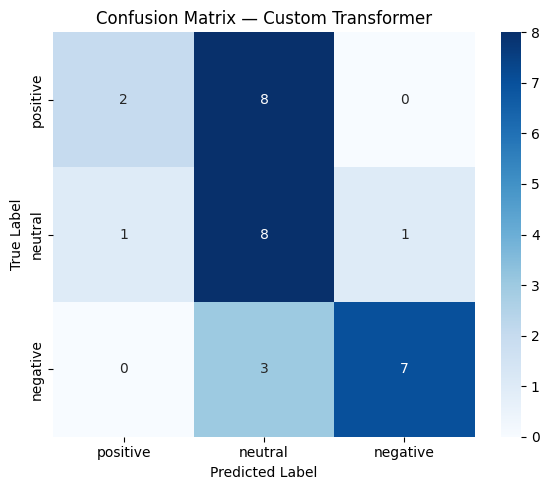


 GPT-2 Fine-tuned — Test Set Results
Accuracy     : 0.7667
F1 Weighted  : 0.7738
F1 Macro     : 0.7738

              precision    recall  f1-score   support

    positive       0.88      0.70      0.78        10
     neutral       0.60      0.90      0.72        10
    negative       1.00      0.70      0.82        10

    accuracy                           0.77        30
   macro avg       0.83      0.77      0.77        30
weighted avg       0.82      0.77      0.77        30



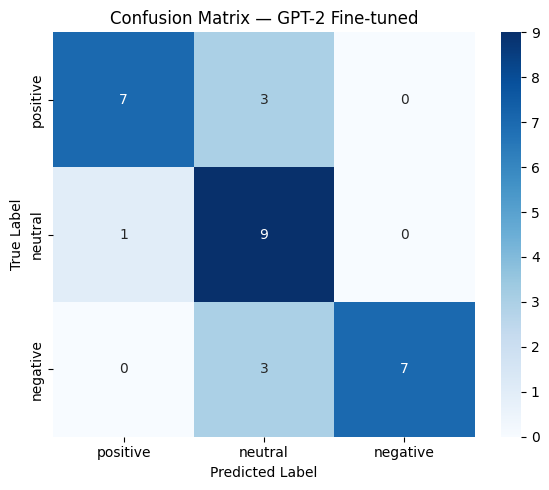

In [21]:
def evaluate_on_test(model, loader, model_name: str):
    """Run inference on test set and print full evaluation report."""
    model.eval()
    all_preds, all_tgts = [], []

    with torch.no_grad():
        for batch in loader:
            inputs  = batch['input_ids'].to(DEVICE)
            targets = batch['labels'].to(DEVICE)
            mask    = batch['attention_mask'].to(DEVICE)
            logits, _ = model(inputs, attention_mask=mask)
            all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            all_tgts.extend(targets.cpu().numpy())

    print(f"\n{'='*50}")
    print(f" {model_name} — Test Set Results")
    print(f"{'='*50}")
    print(f"Accuracy     : {accuracy_score(all_tgts, all_preds):.4f}")
    print(f"F1 Weighted  : {f1_score(all_tgts, all_preds, average='weighted', zero_division=0):.4f}")
    print(f"F1 Macro     : {f1_score(all_tgts, all_preds, average='macro',    zero_division=0):.4f}")
    print()
    print(classification_report(all_tgts, all_preds,
                                 target_names=LABEL_NAMES, zero_division=0))

    cm = confusion_matrix(all_tgts, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return all_preds, all_tgts


# Load best checkpoints before evaluation
model_scratch.load_state_dict(torch.load('models/scratch_best.pt', map_location=DEVICE))
model_ft.load_state_dict(torch.load('models/gpt2_best.pt',         map_location=DEVICE))

# Evaluate both models
preds_scratch, tgts = evaluate_on_test(model_scratch, test_loader, "Custom Transformer")
preds_ft,      _    = evaluate_on_test(model_ft,      test_loader, "GPT-2 Fine-tuned")


In [22]:
# ── Summary comparison table ──────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Custom Transformer (scratch)', 'GPT-2 Fine-tuned'],
    'Accuracy': [
        accuracy_score(tgts, preds_scratch),
        accuracy_score(tgts, preds_ft)
    ],
    'F1 Weighted': [
        f1_score(tgts, preds_scratch, average='weighted', zero_division=0),
        f1_score(tgts, preds_ft,      average='weighted', zero_division=0)
    ],
    'F1 Macro': [
        f1_score(tgts, preds_scratch, average='macro', zero_division=0),
        f1_score(tgts, preds_ft,      average='macro', zero_division=0)
    ]
}).set_index('Model').round(4)

print("\nModel Comparison on Test Set:")
print(results.to_string())


Model Comparison on Test Set:
                              Accuracy  F1 Weighted  F1 Macro
Model                                                        
Custom Transformer (scratch)    0.5667       0.5457    0.5457
GPT-2 Fine-tuned                0.7667       0.7738    0.7738
